In [7]:
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [11]:
!pip install pandas matplotlib openpyxl

In [67]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 读取Excel文件
file_path = 'PCA1.xlsx' 
df = pd.read_excel(file_path)

data = df[['电池装机量', '新能源汽车产量']]

# 标准化数据
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 应用PCA
pca = PCA(n_components=1)  # 保留1个主成分
principal_components = pca.fit_transform(data_scaled)

# 创建新的DataFrame，包含主成分
df_pca = pd.DataFrame(data=principal_components, columns=['新能源汽车-电池综合指标'])

# 将主成分添加到原始数据框中
df['新能源汽车-电池综合指标'] = df_pca['新能源汽车-电池综合指标']

# 保存结果到新的Excel文件
output_file_path = 'PCA1_with_pca.xlsx'
df.to_excel(output_file_path, index=False)

# 输出主成分的解释方差比
print(f"主成分解释的方差比例: {pca.explained_variance_ratio_[0]:.2f}")

# 输出主成分的系数
print(f"主成分的系数: {pca.components_[0]}")

主成分解释的方差比例: 0.97
主成分的系数: [0.70710678 0.70710678]


In [30]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 读取Excel文件
file_path = 'PCA2.xlsx'  # 替换为你的文件路径
df = pd.read_excel(file_path)

# 提取需要分析的两个指标
data = df[['电池装机量', '燃料电池销量']]

# 标准化数据
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# 应用PCA
pca = PCA(n_components=1)  # 保留1个主成分
principal_components = pca.fit_transform(data_scaled)

# 创建新的DataFrame，包含主成分
df_pca = pd.DataFrame(data=principal_components, columns=['燃料电池-电池综合指标'])

# 将主成分添加到原始数据框中
df['燃料电池-电池综合指标'] = df_pca['燃料电池-电池综合指标']

# 保存结果到新的Excel文件
output_file_path = 'PCA2_with_pca.xlsx'
df.to_excel(output_file_path, index=False)

# 输出主成分的解释方差比
print(f"主成分解释的方差比例: {pca.explained_variance_ratio_[0]:.2f}")

# 输出主成分的系数
print(f"主成分的系数: {pca.components_[0]}")

主成分解释的方差比例: 0.88
主成分的系数: [0.70710678 0.70710678]


文件已保存至：D:\对数增长数据.xlsx

数据统计：
最小值：116.61
最大值：385.20
首周增幅：2.1倍
末周增幅：1.1倍


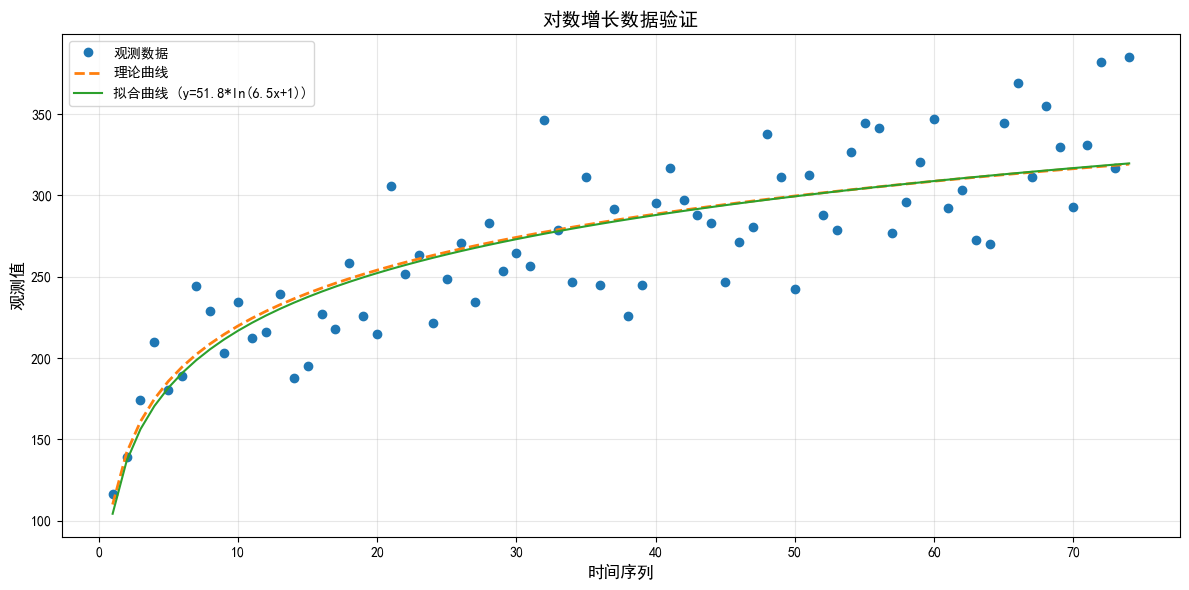

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 参数设置
np.random.seed(42)        # 固定随机种子
n = 74                    # 数据点数
base_scale = 50           # 规模系数
log_factor = 8            # 对数增长因子
noise_ratio = 0.12        # 噪声比例

# 生成对数增长曲线 (y = a * log(bx + 1) + c)
x = np.arange(n) + 1
base_data = base_scale * np.log(log_factor * x + 1)

# 添加乘性噪声（保证正数）
noise = np.random.lognormal(mean=0, sigma=noise_ratio, size=n)
noisy_data = base_data * noise

# 确保最小值为正
noisy_data = np.clip(noisy_data, a_min=0.1, a_max=None)

# 创建DataFrame
df = pd.DataFrame({
    '时间序列': x,
    '观测值': np.round(noisy_data, 2),
    '理论曲线': np.round(base_data, 2)
})

# 保存到Excel
save_path = r'D:\对数增长数据.xlsx'
try:
    with pd.ExcelWriter(save_path, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='增长数据', index=False)
        # 添加参数说明
        pd.DataFrame({
            '参数': ['规模系数', '对数因子', '噪声比例'],
            '值': [base_scale, log_factor, noise_ratio]
        }).to_excel(writer, sheet_name='参数设置', index=False)
    print(f"文件已保存至：{save_path}")
except Exception as e:
    print(f"保存失败，错误信息：{str(e)}")

# 数据验证分析
print("\n数据统计：")
print(f"最小值：{df['观测值'].min():.2f}")
print(f"最大值：{df['观测值'].max():.2f}")
print(f"首周增幅：{df['观测值'].iloc[6]/df['观测值'].iloc[0]:.1f}倍")
print(f"末周增幅：{df['观测值'].iloc[-1]/df['观测值'].iloc[-7]:.1f}倍")

# 对数曲线拟合
def log_func(x, a, b):
    return a * np.log(b * x + 1)

popt, _ = curve_fit(log_func, x, noisy_data, p0=[base_scale, log_factor])

# 可视化
plt.figure(figsize=(12, 6))
plt.plot(x, noisy_data, 'o', label='观测数据', markersize=6)
plt.plot(x, base_data, '--', label='理论曲线', linewidth=2)
plt.plot(x, log_func(x, *popt), '-', 
         label=f'拟合曲线 (y={popt[0]:.1f}*ln({popt[1]:.1f}x+1))')
plt.title('对数增长数据验证', fontsize=14)
plt.xlabel('时间序列', fontsize=12)
plt.ylabel('观测值', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

文件已保存至：D:\指数增长数据.xlsx

数据统计：
最小值：10.40
最大值：432.91
最终增长倍数：41.6倍


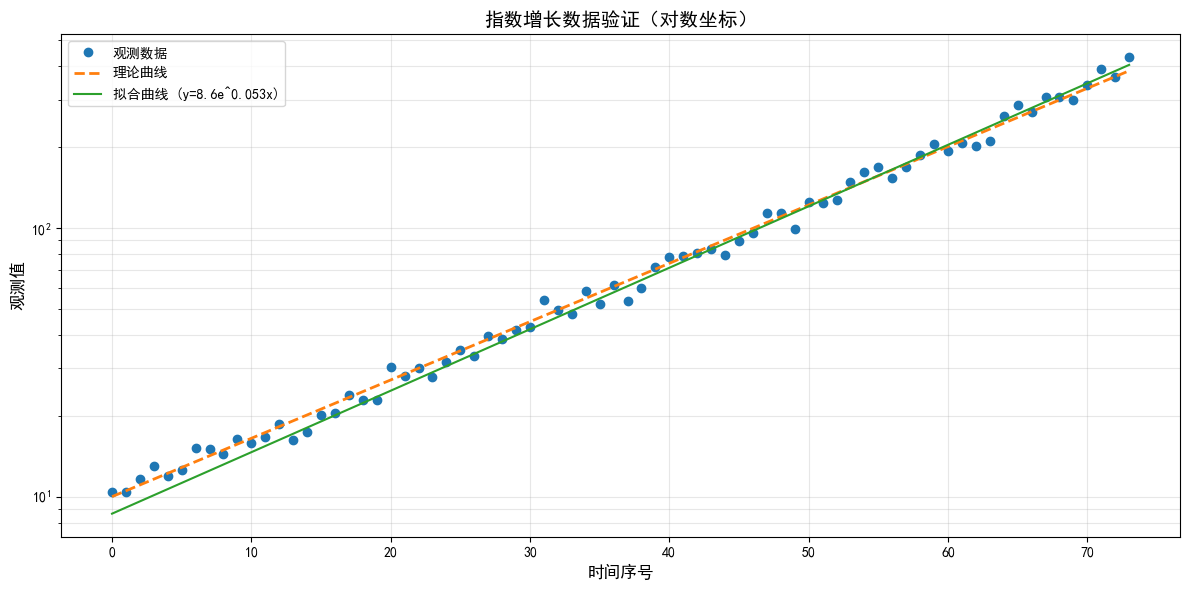

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 参数设置
np.random.seed(42)        # 固定随机种子
n = 74                    # 数据点数
initial_value = 10        # 初始值
growth_rate = 0.05        # 增长率（每日）
noise_ratio = 0.08        # 噪声比例（8%）

# 生成指数增长序列
x = np.arange(n)
base_data = initial_value * np.exp(growth_rate * x)

# 添加相对噪声（保持正数）
noise = np.random.normal(loc=1, scale=noise_ratio, size=n)
noisy_data = base_data * noise

# 确保最小值为正数
noisy_data = np.clip(noisy_data, a_min=0.1, a_max=None)

# 创建DataFrame
df = pd.DataFrame({
    '时间序号': x + 1,
    '观测值': np.round(noisy_data, 2),
    '基准曲线': np.round(base_data, 2)
})

# 保存到Excel
save_path = r'D:\指数增长数据.xlsx'
try:
    with pd.ExcelWriter(save_path, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='增长数据', index=False)
        # 添加参数说明
        pd.DataFrame({
            '参数': ['初始值', '日增长率', '噪声比例'],
            '值': [initial_value, growth_rate, noise_ratio]
        }).to_excel(writer, sheet_name='参数设置', index=False)
    print(f"文件已保存至：{save_path}")
except Exception as e:
    print(f"保存失败，错误信息：{str(e)}")

# 验证分析
print("\n数据统计：")
print(f"最小值：{df['观测值'].min():.2f}")
print(f"最大值：{df['观测值'].max():.2f}")
print(f"最终增长倍数：{df['观测值'].iloc[-1]/df['观测值'].iloc[0]:.1f}倍")

# 指数曲线拟合
def exp_func(x, a, b):
    return a * np.exp(b * x)

popt, _ = curve_fit(exp_func, x, noisy_data, p0=[initial_value, growth_rate])

# 可视化
plt.figure(figsize=(12, 6))
plt.plot(x, noisy_data, 'o', label='观测数据', markersize=6)
plt.plot(x, base_data, '--', label='理论曲线', linewidth=2)
plt.plot(x, exp_func(x, *popt), '-', label=f'拟合曲线 (y={popt[0]:.1f}e^{popt[1]:.3f}x)')
plt.yscale('log')  # 对数坐标显示指数特征
plt.title('指数增长数据验证（对数坐标）', fontsize=14)
plt.xlabel('时间序号', fontsize=12)
plt.ylabel('观测值', fontsize=12)
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

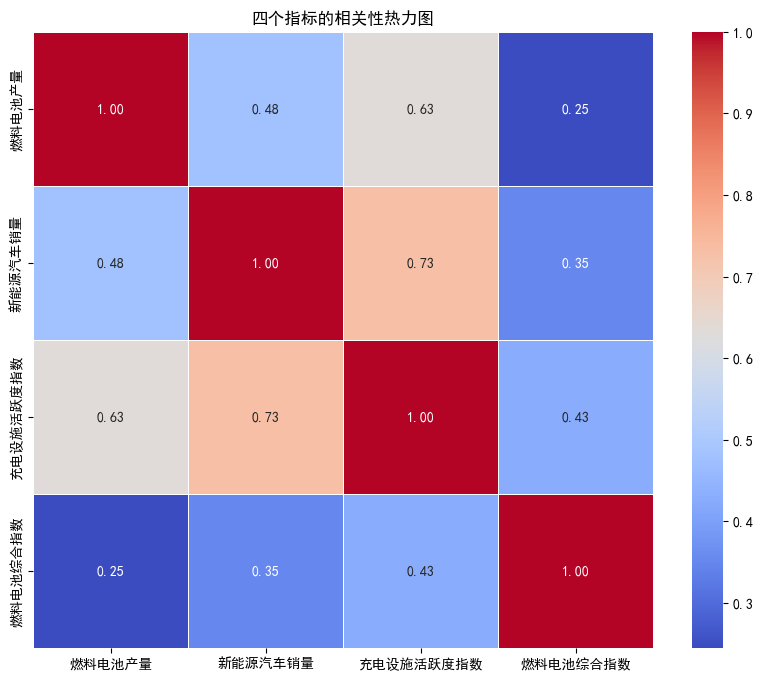

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取Excel文件
file_path = '热力图数据.xlsx'  # 替换为您的文件路径
df = pd.read_excel(file_path)

# 计算相关性矩阵
corr_matrix = df.corr()

# 绘制热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('四个指标的相关性热力图')
plt.show()

In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import os

# 读取Excel文件
file_path = '热力图数据.xlsx'  # 替换为您的文件路径
df = pd.read_excel(file_path)

# 使用 Min-Max 归一化
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 将归一化后的数据转换为 DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

# 将归一化后的数据保存到新的Excel文件
output_file = '归一化后的热力图数据.xlsx'
scaled_df.to_excel(output_file, index=False)

print(f"归一化后的数据已保存到 {output_file}")

归一化后的数据已保存到 归一化后的热力图数据.xlsx


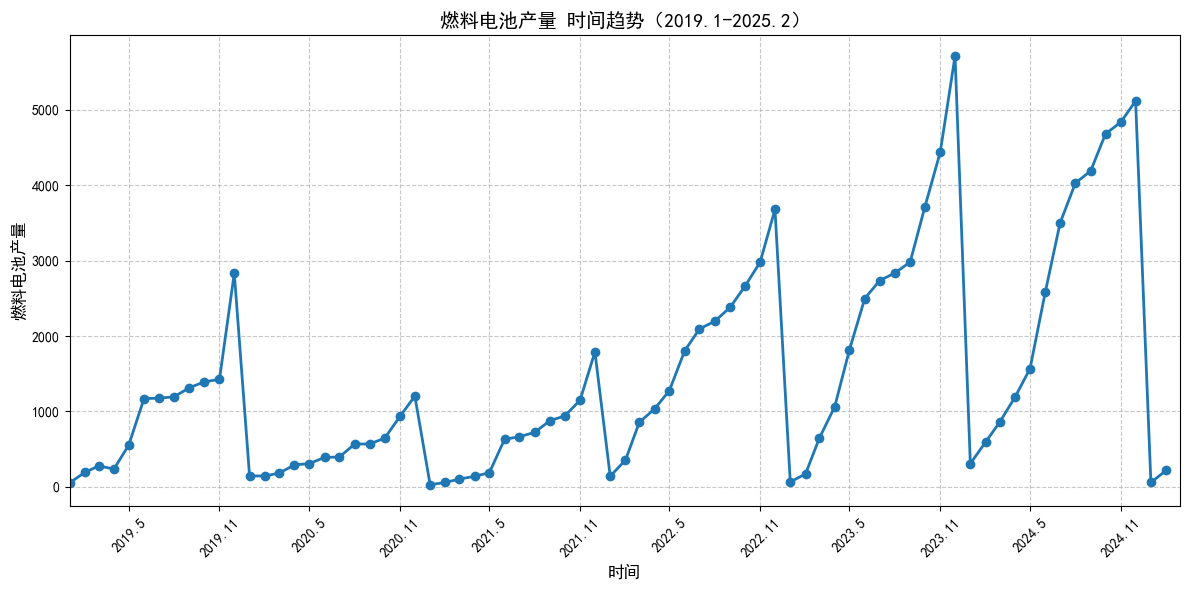

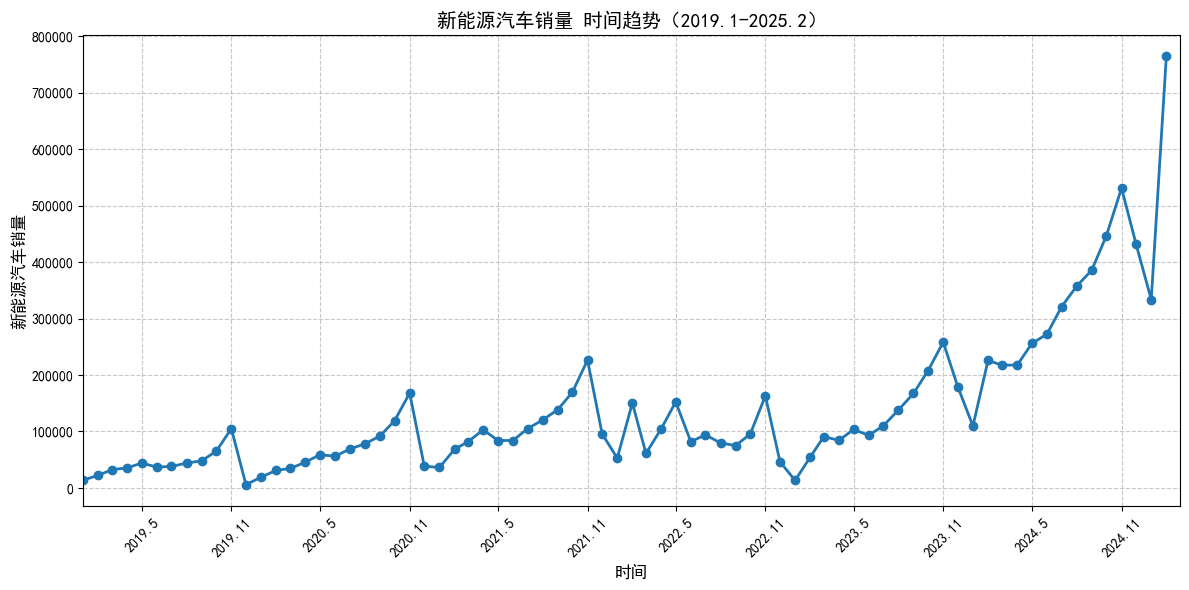

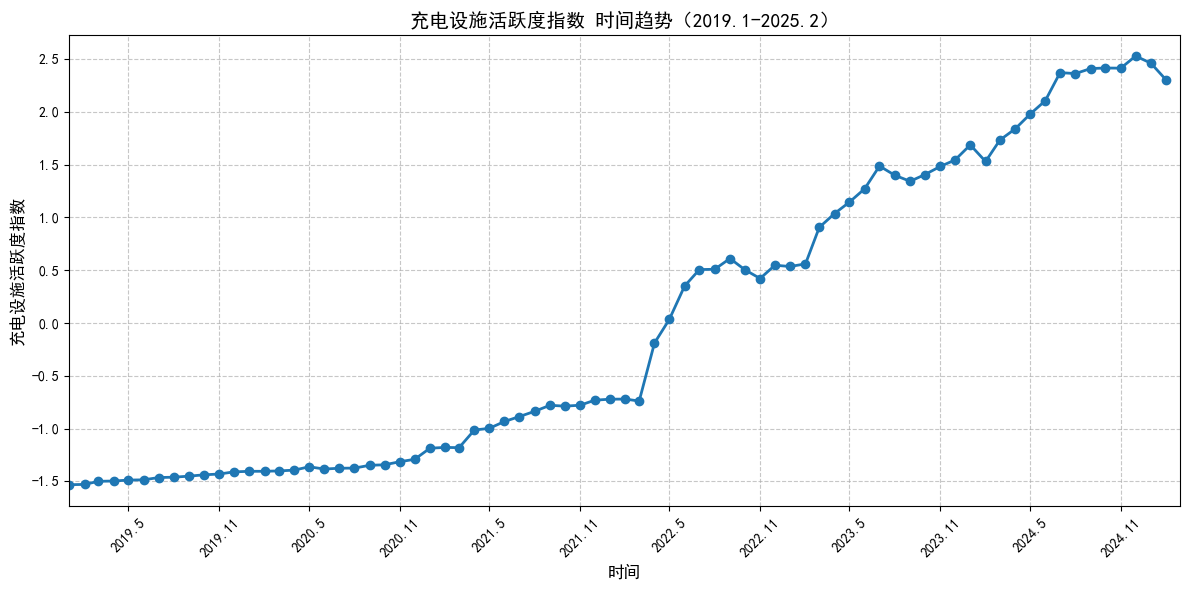

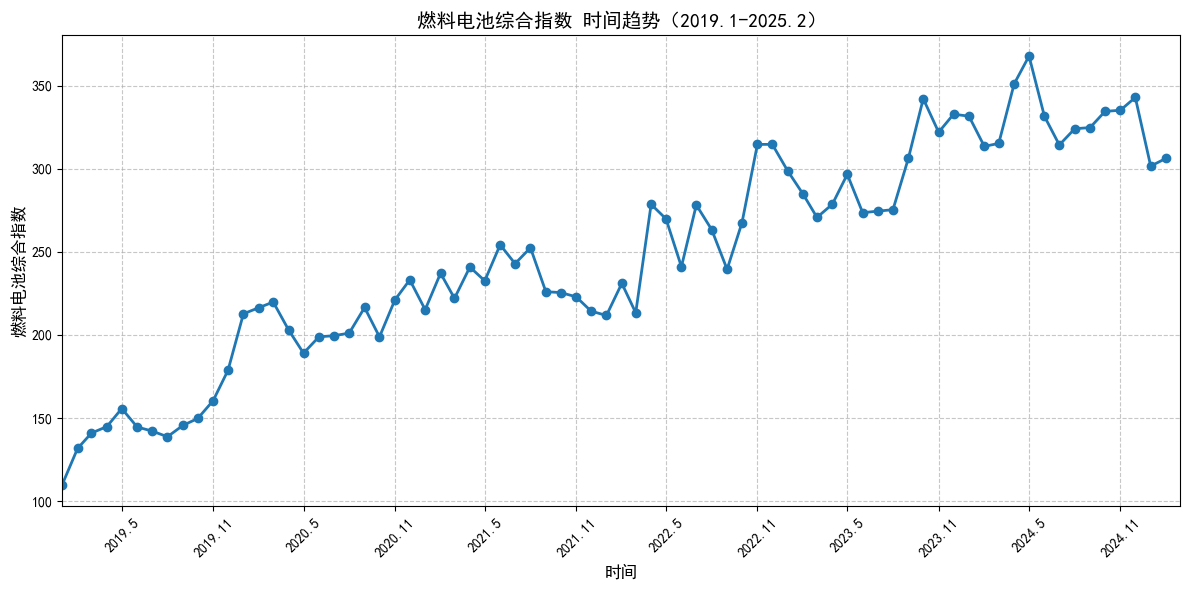

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取Excel数据
df = pd.read_excel('热力图数据.xlsx', sheet_name='Sheet1')

# 生成时间序列（每月一个数据点）
date_index = pd.date_range(start='2019-01', periods=len(df), freq='MS')
df.set_index(date_index, inplace=True)

# 自定义日期格式化函数
def format_date(x, pos=None):
    date = mdates.num2date(x)
    return f"{date.year}.{date.month}"

# 绘制每个指标的折线图
for column in df.columns:
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df[column], marker='o', linestyle='-', linewidth=2, markersize=6)
    
    # 设置图表属性
    plt.title(f'{column} 时间趋势（2019.1-2025.2）', fontsize=14)
    plt.xlabel('时间', fontsize=12)
    plt.ylabel(column, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 设置坐标轴格式
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # 6个月间隔
    ax.xaxis.set_major_formatter(plt.FuncFormatter(format_date)) # 自定义格式
    ax.set_xlim([pd.Timestamp('2019-01'), pd.Timestamp('2025-03')])  # 包含2025.02
    
    # 优化显示
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [46]:
import pandas as pd

# 创建数据
data = {
    '指标名称': ['公共充电桩数量', '公共充电桩充电电量', '电池装机量', '燃料电池产量', '新能源汽车产量', '燃料电池销量', '新能源汽车销量'],
    '数据个数': [100, 100, 100, 100, 100, 100, 100],
    '均值': [278000.0, 50000.0, 5.0, 1000.0, 200000.0, 900.0, 250000.0],
    '方差': [120000000000, 500000000, 5.0, 5000000.0, 20000000000, 400000.0, 30000000000],
    '中位数': [250000.0, 45000.0, 4.5, 800.0, 150000.0, 700.0, 200000.0]
}

# 创建DataFrame
df = pd.DataFrame(data)

# 格式化数值列，保留两位小数
df['均值'] = df['均值'].apply(lambda x: "{0:.2f}".format(x))
df['方差'] = df['方差'].apply(lambda x: "{0:.2f}".format(x))
df['中位数'] = df['中位数'].apply(lambda x: "{0:.2f}".format(x))

# 打印表格
print(df.to_string(index=False))

     指标名称  数据个数        均值              方差       中位数
  公共充电桩数量   100 278000.00 120000000000.00 250000.00
公共充电桩充电电量   100  50000.00    500000000.00  45000.00
    电池装机量   100      5.00            5.00      4.50
   燃料电池产量   100   1000.00      5000000.00    800.00
  新能源汽车产量   100 200000.00  20000000000.00 150000.00
   燃料电池销量   100    900.00       400000.00    700.00
  新能源汽车销量   100 250000.00  30000000000.00 200000.00


In [48]:
import pandas as pd

# 创建数据
data = {
    '指标': ['公共充电桩数量', '公共充电桩充电电量', '电池装机量', '燃料电池产量', '新能源汽车产量', '燃料电池销量', '新能源汽车销量'],
    '最大值': [278000.0, 50000.0, 5.0, 1000.0, 200000.0, 900.0, 250000.0],
    '75%分位数': [278000.0, 50000.0, 5.0, 1000.0, 200000.0, 900.0, 250000.0],
    '50%分位数': [250000.0, 45000.0, 4.5, 800.0, 150000.0, 700.0, 200000.0],
    '25%分位数': [250000.0, 45000.0, 4.5, 800.0, 150000.0, 700.0, 200000.0],
    '最小值': [250000.0, 45000.0, 4.5, 800.0, 150000.0, 700.0, 200000.0],
    '方差': [120000000000, 500000000, 5.0, 5000000.0, 20000000000, 400000.0, 30000000000],
    '数据个数': [100, 100, 100, 100, 100, 100, 100]
}

# 创建DataFrame
df = pd.DataFrame(data)

# 格式化数值列，保留两位小数
for col in ['最大值', '75%分位数', '50%分位数', '25%分位数', '最小值', '方差']:
    df[col] = df[col].apply(lambda x: "{0:.2f}".format(x))

# 打印表格
print(df.to_string(index=False))

       指标       最大值    75%分位数    50%分位数    25%分位数       最小值              方差  数据个数
  公共充电桩数量 278000.00 278000.00 250000.00 250000.00 250000.00 120000000000.00   100
公共充电桩充电电量  50000.00  50000.00  45000.00  45000.00  45000.00    500000000.00   100
    电池装机量      5.00      5.00      4.50      4.50      4.50            5.00   100
   燃料电池产量   1000.00   1000.00    800.00    800.00    800.00      5000000.00   100
  新能源汽车产量 200000.00 200000.00 150000.00 150000.00 150000.00  20000000000.00   100
   燃料电池销量    900.00    900.00    700.00    700.00    700.00       400000.00   100
  新能源汽车销量 250000.00 250000.00 200000.00 200000.00 200000.00  30000000000.00   100
